In [2]:
import onnxruntime as ort

In [11]:
onnx_model_path = "/Users/fdl/Downloads/hair_classifier_v1.onnx"
session = ort.InferenceSession(onnx_model_path, providers=['CPUExecutionProvider'])

In [12]:
inputs = session.get_inputs()
outputs = session.get_outputs()

input_name = inputs[0].name
output_name = outputs[0].name

In [15]:
# question 1
output_name

'output'

In [ ]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

In [19]:
# question 2
url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"

img = download_image(url)
img = prepare_image(img, target_size=(200, 200))

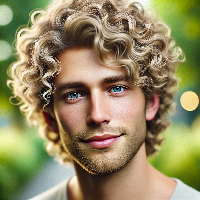

In [20]:
img

In [26]:
from torchvision import transforms

inference_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

img_tensor = inference_transforms(img).unsqueeze(0)
img_tensor.shape

torch.Size([1, 3, 200, 200])

In [34]:
r_value = img_tensor[0, 0, 0, 0].item()
print(r_value)

-1.0732940435409546


In [36]:
preds = session.run([output_name], {input_name: img_tensor.numpy()})
preds[0][0].tolist()

[0.09156588464975357]

In [37]:
from PIL import Image

local_image_path = "/Users/fdl/Downloads/prueba_modelo.png"
img = Image.open(local_image_path)
img = prepare_image(img, target_size=(200, 200))
img_tensor = inference_transforms(img).unsqueeze(0)

preds = session.run([output_name], {input_name: img_tensor.numpy()})
preds[0][0].tolist()

[-5.14841365814209]

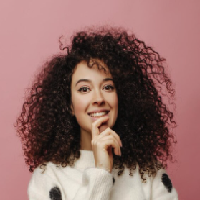

In [38]:
img